In [10]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from data_utils import (
    DATA_DIR,
    make_transforms,
    make_dataloaders,
)

In [11]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: mps


In [12]:
METADATA_DIR = PROJECT_DIR / "outputs" / "results"

SPLIT_PATH = METADATA_DIR / "data_split.csv"
CLASS_NAMES_PATH = METADATA_DIR / "class_names.json"

split_df = pd.read_csv(SPLIT_PATH)

with open(CLASS_NAMES_PATH, "r", encoding="utf-8") as f:
    class_names = json.load(f)

num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Number of images:", len(split_df))

print("\nSplit counts:")
print(split_df["split"].value_counts())

Number of classes: 38
Number of images: 54284

Split counts:
split
train         37984
test          10873
validation     5427
Name: count, dtype: int64


In [13]:
IMAGE_SIZE = 128

train_transform, eval_transform = make_transforms(
    image_size=IMAGE_SIZE
)

In [14]:
BATCH_SIZE = 64

train_loader, val_loader, test_loader = make_dataloaders(
    split_df=split_df,
    data_dir=DATA_DIR,
    train_transform=train_transform,
    eval_transform=eval_transform,
    batch_size=BATCH_SIZE,
    num_workers=0,
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 594
Validation batches: 85
Test batches: 170


In [15]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("Image dtype:", images.dtype)
print("Min pixel:", images.min().item())
print("Max pixel:", images.max().item())

print("First labels:", labels[:10])

Image batch shape: torch.Size([64, 3, 128, 128])
Label batch shape: torch.Size([64])
Image dtype: torch.float32
Min pixel: 0.0
Max pixel: 0.9843137264251709
First labels: tensor([24, 30, 13, 32, 37, 24,  0, 35,  8, 30])


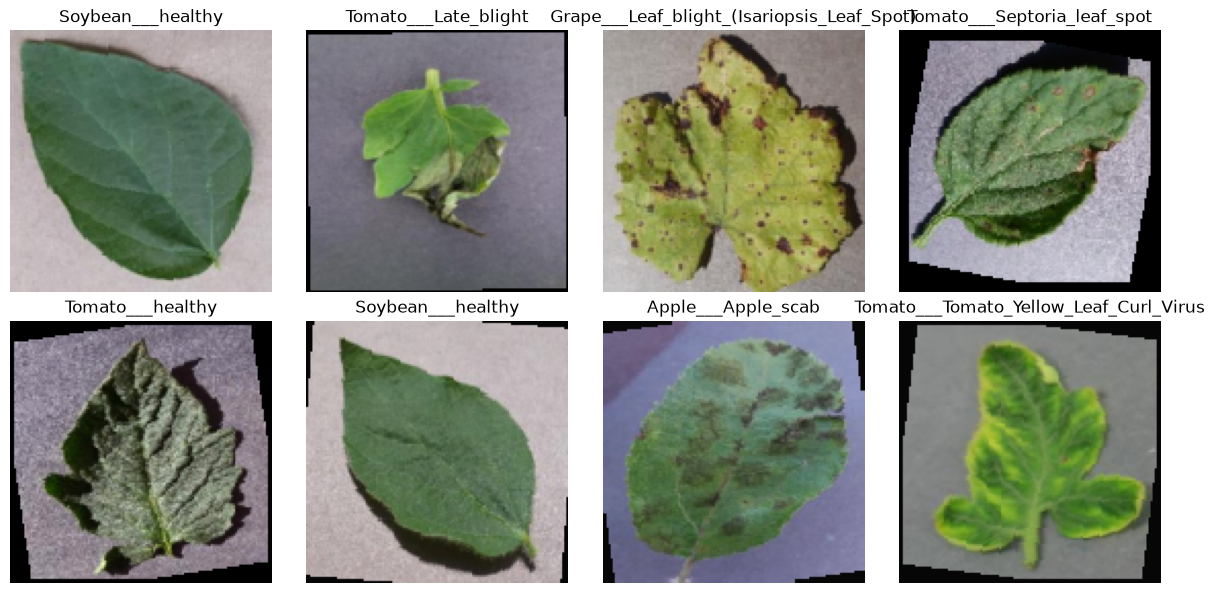

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    image = images[i].permute(1, 2, 0).numpy()
    label = labels[i].item()

    ax.imshow(image)
    ax.set_title(class_names[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [17]:
class BasicCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [18]:
model = BasicCNN(
    num_classes=num_classes
).to(device)

print(model)

BasicCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine

In [19]:
total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 427,174
Trainable parameters: 427,174


In [20]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [21]:
def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        # Reset gradient
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # Loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predictions = torch.max(outputs, 1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [22]:
def evaluate(
    model,
    dataloader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item()
                * images.size(0)
            )

            _, predictions = torch.max(
                outputs,
                1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [23]:
EPOCHS = 10

In [24]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
    )

    val_loss, val_acc = evaluate(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device,
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/10] | Train Loss: 1.5569 | Train Acc: 0.5559 | Val Loss: 1.9362 | Val Acc: 0.5145
Epoch [2/10] | Train Loss: 0.8107 | Train Acc: 0.7510 | Val Loss: 0.6666 | Val Acc: 0.7886
Epoch [3/10] | Train Loss: 0.5692 | Train Acc: 0.8245 | Val Loss: 0.6021 | Val Acc: 0.8060
Epoch [4/10] | Train Loss: 0.4391 | Train Acc: 0.8642 | Val Loss: 0.4589 | Val Acc: 0.8507
Epoch [5/10] | Train Loss: 0.3702 | Train Acc: 0.8826 | Val Loss: 1.1021 | Val Acc: 0.7301
Epoch [6/10] | Train Loss: 0.3309 | Train Acc: 0.8950 | Val Loss: 0.3361 | Val Acc: 0.8885
Epoch [7/10] | Train Loss: 0.2928 | Train Acc: 0.9072 | Val Loss: 0.2327 | Val Acc: 0.9254
Epoch [8/10] | Train Loss: 0.2681 | Train Acc: 0.9143 | Val Loss: 0.4583 | Val Acc: 0.8498
Epoch [9/10] | Train Loss: 0.2512 | Train Acc: 0.9190 | Val Loss: 0.1494 | Val Acc: 0.9484
Epoch [10/10] | Train Loss: 0.2243 | Train Acc: 0.9283 | Val Loss: 0.1531 | Val Acc: 0.9501


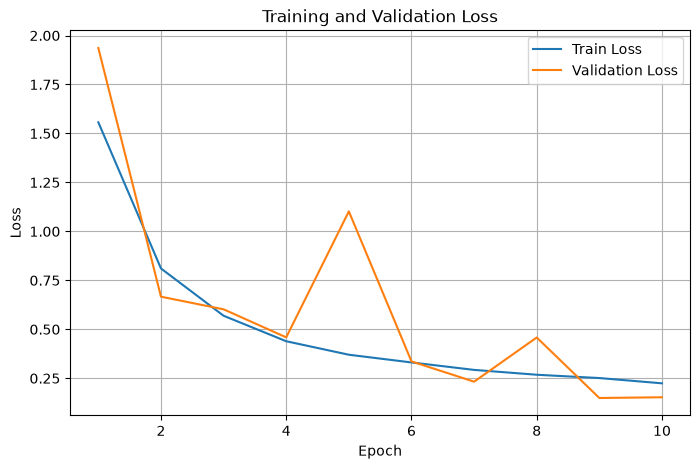

In [25]:
epochs = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()

plt.show()

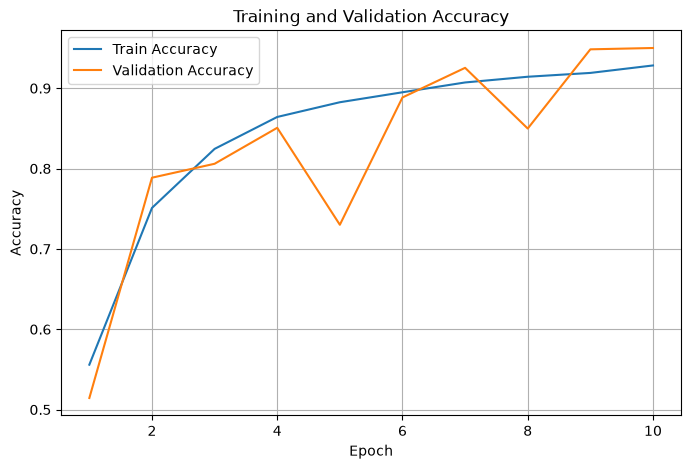

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

In [27]:
test_loss, test_accuracy = evaluate(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device,
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.1527
Test Accuracy: 0.9473


In [28]:
all_labels = []
all_predictions = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

print("Number of test samples:", len(all_labels))

Number of test samples: 10873


In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.9473
Precision: 0.9500
Recall   : 0.9473
F1-score : 0.9468


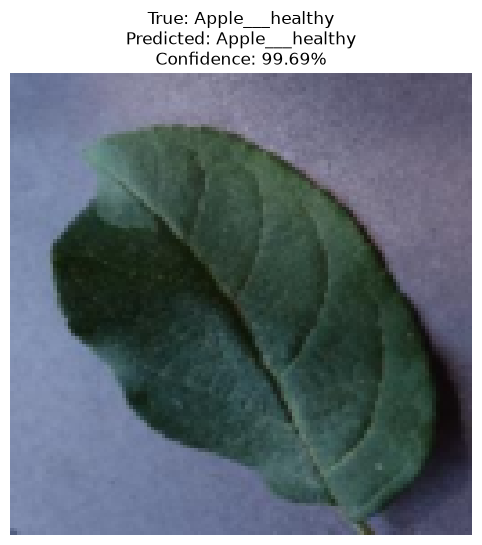

True class      : Apple___healthy
Predicted class : Apple___healthy
Confidence      : 99.69%


In [49]:
import random
import matplotlib.pyplot as plt

# Lấy dataset của test_loader
test_dataset = test_loader.dataset

# Chọn ngẫu nhiên một ảnh
random_index = random.randint(0, len(test_dataset) - 1)

image, true_label = test_dataset[random_index]

# Thêm batch dimension: [3, H, W] -> [1, 3, H, W]
input_image = image.unsqueeze(0).to(device)

# Predict
model.eval()

with torch.no_grad():
    output = model(input_image)

    probabilities = torch.softmax(output, dim=1)

    predicted_label = probabilities.argmax(dim=1).item()
    confidence = probabilities[0, predicted_label].item()

# Lấy tên class
true_class = class_names[true_label]
predicted_class = class_names[predicted_label]

# Hiển thị ảnh
display_image = image.permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(6, 6))
plt.imshow(display_image)
plt.axis("off")

plt.title(
    f"True: {true_class}\n"
    f"Predicted: {predicted_class}\n"
    f"Confidence: {confidence:.2%}"
)

plt.show()

print("True class      :", true_class)
print("Predicted class :", predicted_class)
print(f"Confidence      : {confidence:.2%}")

In [44]:
top_probs, top_indices = torch.topk(
    probabilities[0],
    k=5
)

print("Top 5 predictions:")

for rank, (prob, idx) in enumerate(
    zip(top_probs, top_indices),
    start=1
):
    print(
        f"{rank}. {class_names[idx.item()]} "
        f"- {prob.item():.2%}"
    )

Top 5 predictions:
1. Tomato___Spider_mites Two-spotted_spider_mite - 99.18%
2. Pepper,_bell___healthy - 0.58%
3. Tomato___Target_Spot - 0.18%
4. Tomato___Tomato_Yellow_Leaf_Curl_Virus - 0.02%
5. Tomato___Late_blight - 0.02%
